In [1]:
import pandas as pd
import mysql.connector
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
conn = mysql.connector.connect(
    host = '127.0.0.1',
    user = 'root',
    password = '401721',
    database = 'pizza_db',
    port = 3306
)

In [3]:
cursor = conn.cursor()

In [4]:
pizza_df = pd.read_sql("SELECT * FROM pizza_sales",conn)
pizza_df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1.0,1.0,hawaiian_m,1.0,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2.0,2.0,classic_dlx_m,1.0,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3.0,2.0,five_cheese_l,1.0,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4.0,2.0,ital_supr_l,1.0,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5.0,2.0,mexicana_m,1.0,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [5]:
df = pizza_df.copy()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  float64
 1   order_id           48620 non-null  float64
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  float64
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(5), object(7)
memory usage: 4.5+ MB


In [7]:
df.isnull().sum()/len(df)*100

pizza_id             0.0
order_id             0.0
pizza_name_id        0.0
quantity             0.0
order_date           0.0
order_time           0.0
unit_price           0.0
total_price          0.0
pizza_size           0.0
pizza_category       0.0
pizza_ingredients    0.0
pizza_name           0.0
dtype: float64

In [8]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

In [9]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


In [10]:
df[['pizza_id', 'order_id', 'quantity']] = df[['pizza_id', 'order_id', 'quantity']].astype(int)

In [11]:
df['order_timestamp'] = df['order_date'] + ' ' + df['order_time']

In [12]:
df['order_timestamp'] = pd.to_datetime(df['order_timestamp'])

In [13]:
df.drop(['order_date','order_time'], axis = 1,inplace = True)

In [14]:
df['day_name'] = df['order_timestamp'].dt.day_name()
df['month_name'] = df['order_timestamp'].dt.month_name()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   pizza_id           48620 non-null  int64         
 1   order_id           48620 non-null  int64         
 2   pizza_name_id      48620 non-null  object        
 3   quantity           48620 non-null  int64         
 4   unit_price         48620 non-null  float64       
 5   total_price        48620 non-null  float64       
 6   pizza_size         48620 non-null  object        
 7   pizza_category     48620 non-null  object        
 8   pizza_ingredients  48620 non-null  object        
 9   pizza_name         48620 non-null  object        
 10  order_timestamp    48620 non-null  datetime64[ns]
 11  day_name           48620 non-null  object        
 12  month_name         48620 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(7)
memory 

In [16]:
df.sample(3)

,pizza_id,order_id,pizza_name_id,quantity,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,order_timestamp,day_name,month_name
3505,3506,1558,veggie_veg_l,1,20.25,20.25,L,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",The Vegetables + Vegetables Pizza,2015-01-27 12:27:55,Tuesday,January
36642,36643,16167,big_meat_s,2,12.00,24.00,S,Classic,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau...",The Big Meat Pizza,2015-09-29 21:45:37,Tuesday,September
26449,26450,11651,sicilian_m,1,16.25,16.25,M,Supreme,"Coarse Sicilian Salami, Tomatoes, Green Olives...",The Sicilian Pizza,2015-07-14 13:05:54,Tuesday,July


## KPI

In [17]:
Total_Revenue = df['total_price'].sum().round(2)
Total_Orders = df['order_id'].nunique()
Total_Pizza_Sold = df['quantity'].sum()
Avarage_Order_Value = (Total_Revenue / Total_Orders).round(2)
Avarage_Pizzas_per_order = (Total_Pizza_Sold/Total_Orders).round(2)

print(f'Total_Revenue : $ {Total_Revenue:,}')
print(f'Total_Orders :  {Total_Orders:,}')
print(f'Total_Pizza_Sold : {Total_Pizza_Sold:,}')
print(f'Avarage_Order_Value : $ {Avarage_Order_Value:,}')
print(f'Avarage_Pizzas_per_order : {Avarage_Pizzas_per_order:,}')

Total_Revenue : $ 817,860.05
Total_Orders :  21,350
Total_Pizza_Sold : 49,574
Avarage_Order_Value : $ 38.31
Avarage_Pizzas_per_order : 2.32


## Vizualizations

### Indgredient Analysis

In [18]:
ingrdients_name = df['pizza_ingredients'].str.split(',').explode().str.strip().reset_index()
ingredients_df = ingrdients_name['pizza_ingredients'].value_counts().reset_index(name = 'use_count')
ingredients_df

,pizza_ingredients,use_count
0,Garlic,27422
1,Tomatoes,26601
2,Red Onions,19547
3,Red Peppers,16284
4,Mozzarella Cheese,10333
...,...,...
60,Brie Carre Cheese,480
61,Prosciutto,480
62,Caramelized Onions,480
63,Pears,480


### Trends

#### Daily Trend - Total Orders

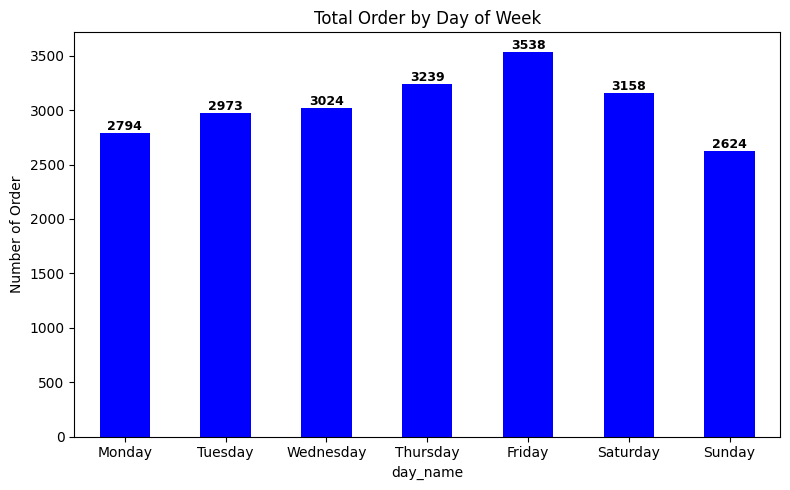

In [19]:
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df['day_name'] = pd.Categorical(df['day_name'], categories=weekdays, ordered=True)
order_by_days = df.groupby(['day_name'], observed=False)['order_id'].nunique()

order_by_days.plot(kind = 'bar', figsize = (8,5), color = 'blue')
plt.title("Total Order by Day of Week")
plt.xlabel
("Day of Week")
plt.ylabel("Number of Order")
plt.xticks(rotation=0)

for i,val in enumerate(order_by_days):
    plt.text(i, val, str(val), ha='center', va='bottom',fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### Daily Trend - Total Revenue

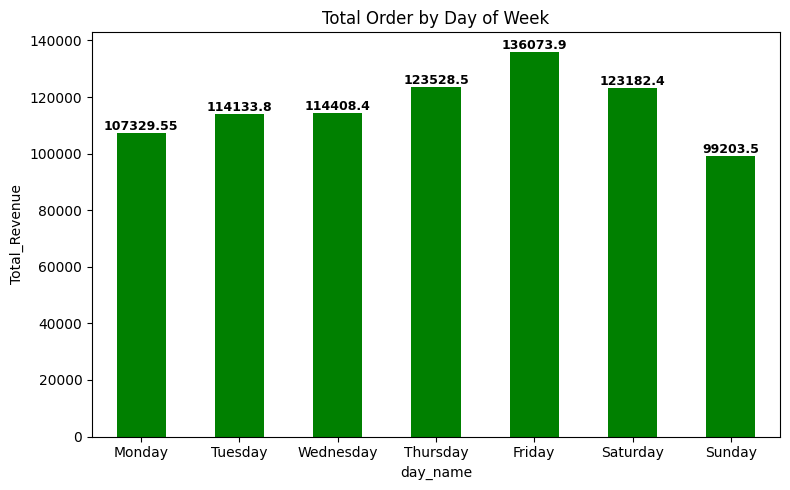

In [20]:
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df['day_name'] = pd.Categorical(df['day_name'], categories=weekdays, ordered=True)

order_by_days = df.groupby(['day_name'], observed=False)['total_price'].sum()

order_by_days.plot(kind = 'bar', figsize = (8,5), color = 'green')
plt.title("Total Order by Day of Week")
plt.xlabel
("Day of Week")
plt.ylabel("Total_Revenue")
plt.xticks(rotation=0)

for i,val in enumerate(order_by_days):
    plt.text(i, val, str(val), ha='center', va='bottom',fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### Hourly_trend - Total Orders

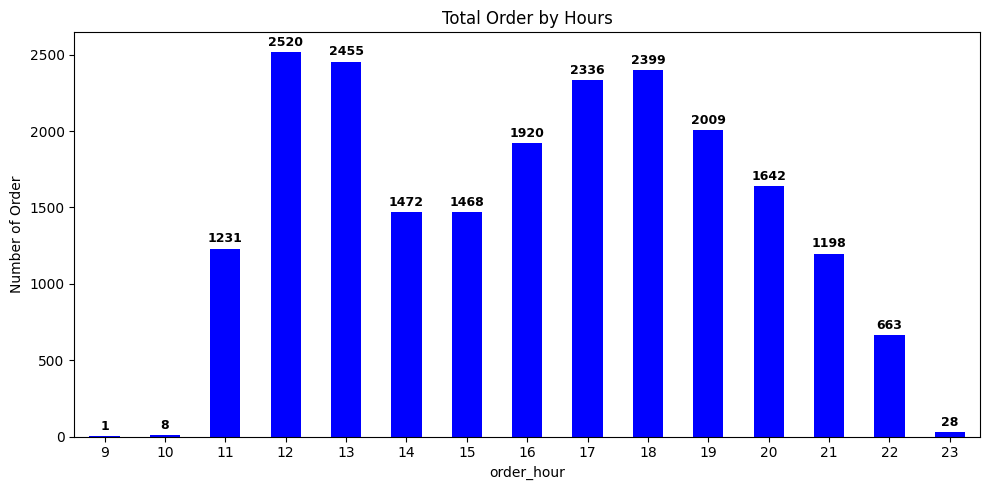

In [21]:
df['order_hour'] = df['order_timestamp'].dt.hour
order_by_hours = df.groupby(['order_hour'], observed=False)['order_id'].nunique()

order_by_hours.plot(kind = 'bar', figsize = (10,5), color = 'blue')
plt.title("Total Order by Hours")
plt.xlabel
("Hours")
plt.ylabel("Number of Order")
plt.xticks(rotation=0)

for i,val in enumerate(order_by_hours):
    plt.text(i, val+20, str(val), ha='center', va='bottom',fontsize=9, fontweight='bold')
    
plt.tight_layout()
plt.show()

#### Hourly_trend - Total Revenue

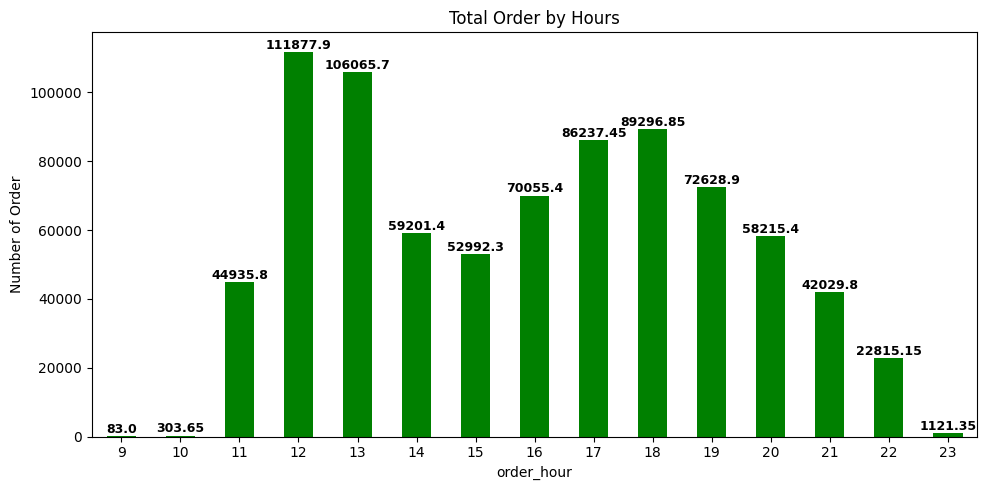

In [22]:
df['order_hour'] = df['order_timestamp'].dt.hour
revenue_by_hours = df.groupby(['order_hour'], observed=False)['total_price'].sum()

revenue_by_hours.plot(kind = 'bar', figsize = (10,5), color = 'green')
plt.title("Total Order by Hours")
plt.xlabel
("Hours")
plt.ylabel("Number of Order")
plt.xticks(rotation=0)

for i,val in enumerate(revenue_by_hours):
    plt.text(i, val+20, str(val), ha='center', va='bottom',fontsize=9, fontweight='bold')
    
plt.tight_layout()
plt.show()

#### Monthly Trend - Total Orders

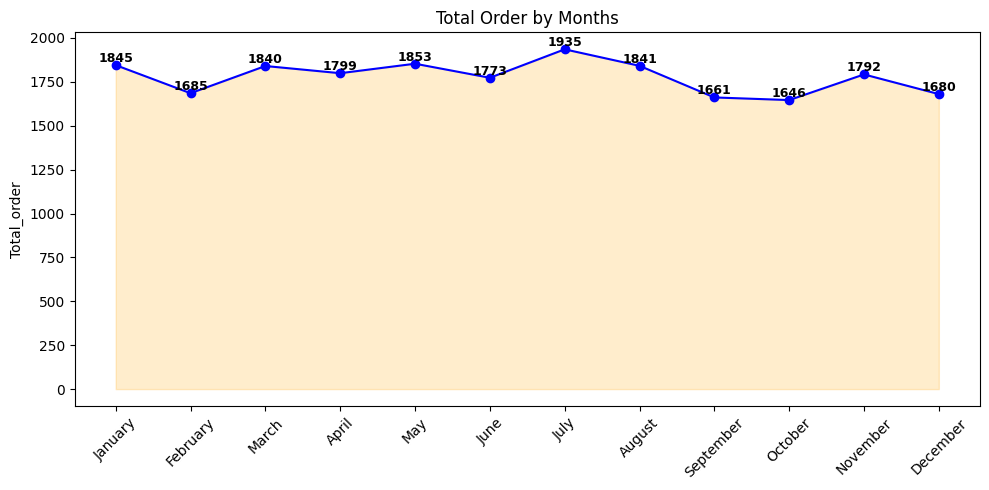

In [23]:
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['month_name'] = pd.Categorical(df['month_name'], categories=months_order, ordered=True)

order_by_months = df.groupby(['month_name'], observed=False)['order_id'].nunique()

plt.figure(figsize = (10,5))
plt.fill_between(order_by_months.index,order_by_months.values,color = 'orange', alpha=0.2)
plt.plot(order_by_months.index,order_by_months.values,color = 'blue', marker='o')

plt.title("Total Order by Months")
plt.xlabel
("Months")
plt.ylabel("Total_order")
plt.xticks(rotation=45)

for i,val in enumerate(order_by_months):
    plt.text(i, val, str(val), ha='center', va='bottom',fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [24]:
order_by_months

month_name
January      1845
February     1685
March        1840
April        1799
May          1853
June         1773
July         1935
August       1841
September    1661
October      1646
November     1792
December     1680
Name: order_id, dtype: int64

#### Monthly Trend - Total Revenue

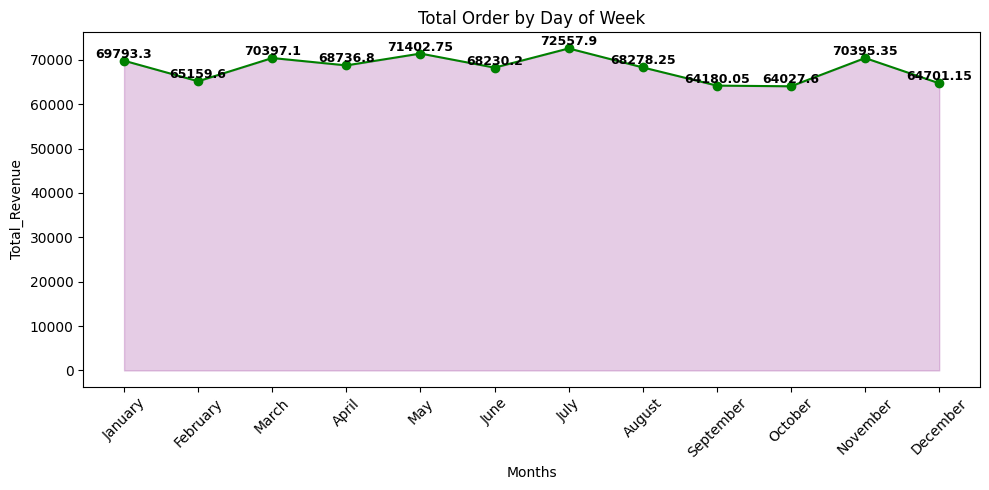

In [25]:
revenue_by_months = df.groupby(['month_name'], observed=False)['total_price'].sum()

plt.figure(figsize = (10,5))
plt.fill_between(revenue_by_months.index,revenue_by_months.values,color = 'purple', alpha=0.2)
plt.plot(revenue_by_months.index,revenue_by_months.values,color = 'green', marker='o')

plt.title("Total Order by Day of Week")
plt.xlabel("Months")
plt.ylabel("Total_Revenue")
plt.xticks(rotation=45)

for i,val in enumerate(revenue_by_months):
    plt.text(i, val, str(val), ha='center', va='bottom',fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Pizza Category analysis

In [26]:
cat_sales = df.groupby('pizza_category')['total_price'].sum()
cat_prct = (cat_sales/cat_sales.sum()*100).round(2)
cat_prct

pizza_category
Chicken    23.96
Classic    26.91
Supreme    25.46
Veggie     23.68
Name: total_price, dtype: float64

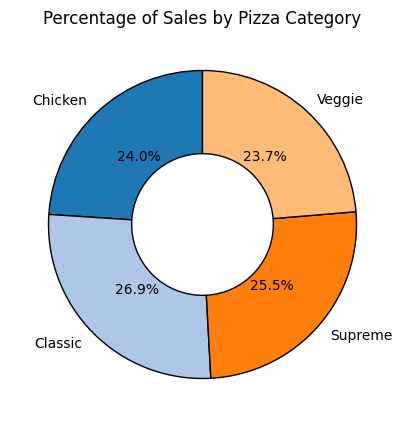

In [27]:
plt.figure(figsize = (5,5))
colors = plt.get_cmap('tab20').colors
plt.pie(cat_prct, labels = cat_prct.index, autopct = '%1.1f%%',colors = colors,startangle = 90, wedgeprops = {'edgecolor' : 'Black', 'width': 0.54})
plt.title("Percentage of Sales by Pizza Category")
plt.show()

Sales (%) by Pizza Size and Category

<Axes: xlabel='pizza_size', ylabel='pizza_category'>

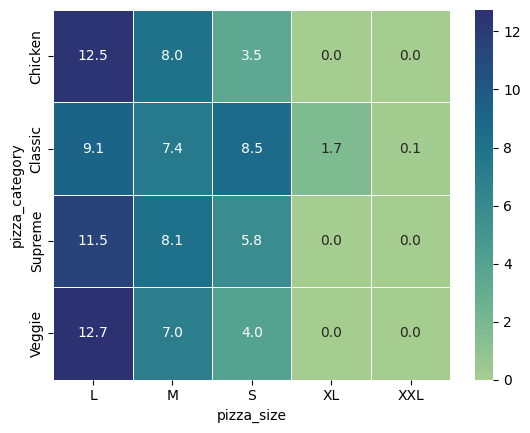

In [28]:
sales_pivot = df.pivot_table(index = 'pizza_category', columns = 'pizza_size', values = 'total_price', aggfunc = 'sum', fill_value=0)
sales_prct = sales_pivot/sales_pivot.sum().sum()*100
sns.heatmap(sales_prct, annot = True, fmt = ".1f", cmap = 'crest',linewidth = 0.5)

Total Pizza  Sold by Pizza category

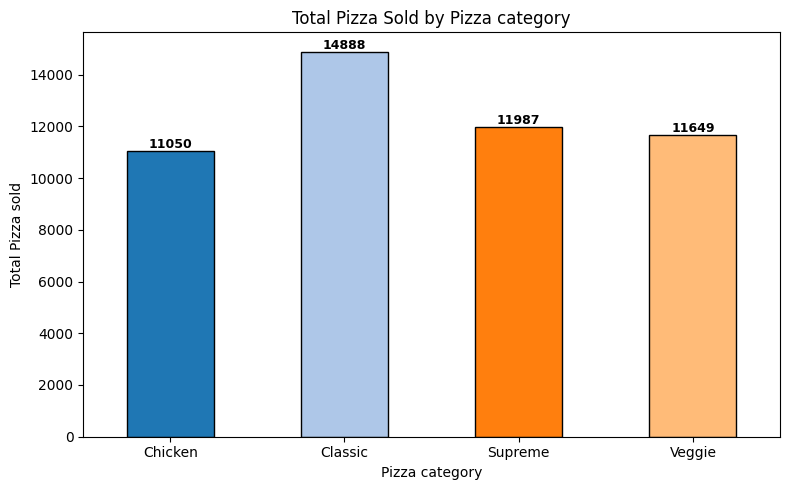

In [30]:
pizza_by_category = df.groupby(['pizza_category'])['quantity'].sum()

colors = list(plt.get_cmap("tab20").colors)
colors = colors[:len(pizza_by_category)]

pizza_by_category.plot(kind = 'bar', figsize = (8,5), color = colors, edgecolor = 'black')

plt.title("Total Pizza Sold by Pizza category")
plt.xlabel("Pizza category")
plt.ylabel("Total Pizza sold")
plt.xticks(rotation=0)

for i,val in enumerate(pizza_by_category):
    plt.text(i, val, str(val), ha='center', va='bottom',fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Best Selling Pizzas

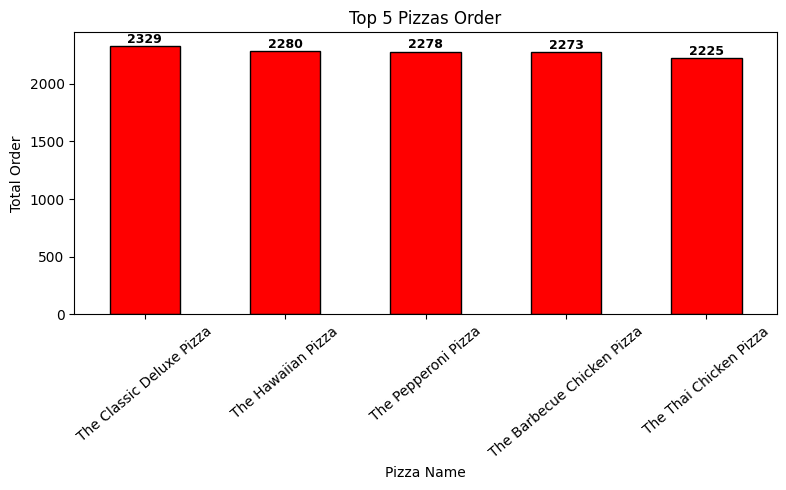

In [33]:
# Top 5 Best-Selling Pizzas - Total Orders
pizzas_by_name = df.groupby('pizza_name')['order_id'].nunique()

top5 = pizzas_by_name.sort_values(ascending=False).head(5)

ax = top5.plot(kind='bar', figsize=(8,5), color='red', edgecolor='black')
plt.title("Top 5 Pizzas Order")
plt.xlabel("Pizza Name")
plt.ylabel("Total Order")
plt.xticks(rotation=40)

for i, val in enumerate(top5):
    plt.text(i, val + 2, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


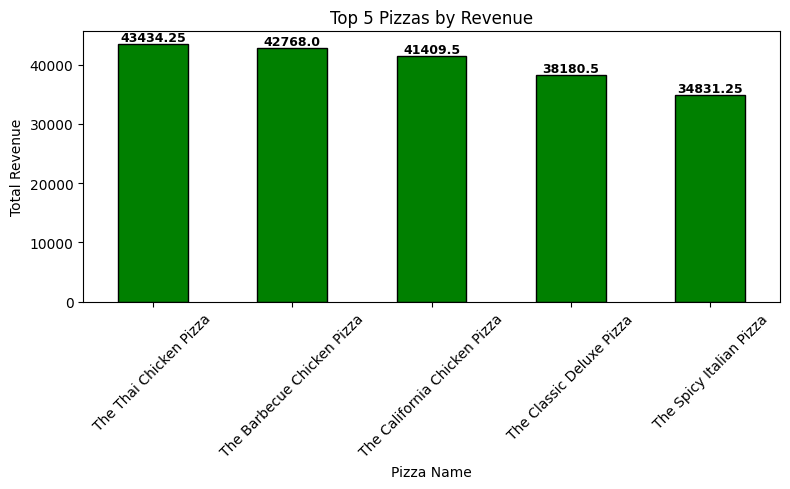

In [34]:
# Top 5 Best-Selling Pizzas - Total Sales
pizzas_by_name = df.groupby('pizza_name')['total_price'].sum()

top5 = pizzas_by_name.sort_values(ascending=False).head(5)

ax = top5.plot(kind='bar', figsize=(8,5), color='green', edgecolor='black')
plt.title("Top 5 Pizzas by Revenue")
plt.xlabel("Pizza Name")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

for i, val in enumerate(top5):
    plt.text(i, val + 2, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


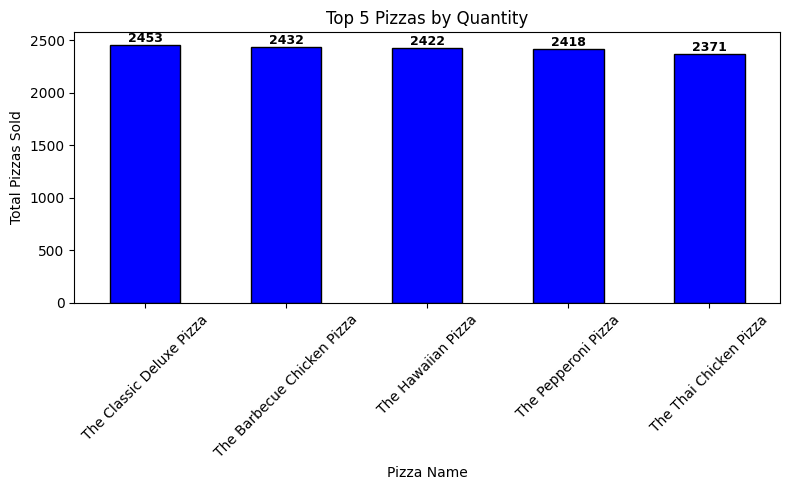

In [35]:
# Top 5 Best-Selling Pizzas - Total Quantity
pizzas_by_name = df.groupby('pizza_name')['quantity'].sum()

top5 = pizzas_by_name.sort_values(ascending=False).head(5)

ax = top5.plot(kind='bar', figsize=(8,5), color='blue', edgecolor='black')
plt.title("Top 5 Pizzas by Quantity")
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

for i, val in enumerate(top5):
    plt.text(i, val + 2, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


### Worst Selling Pizzas

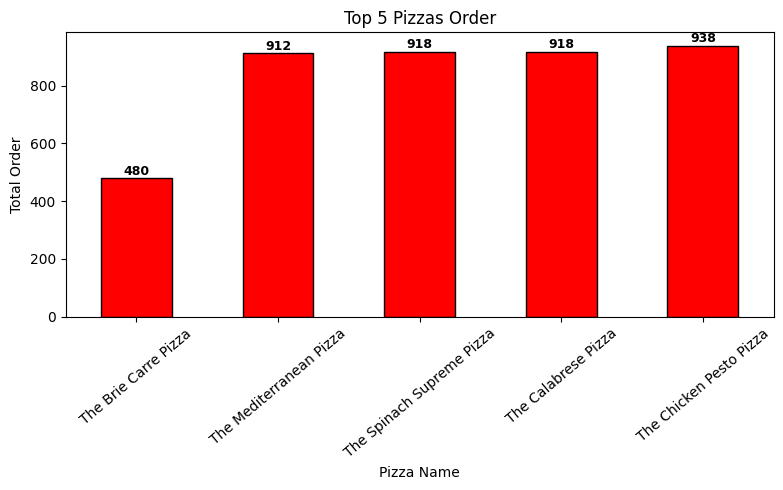

In [36]:
# Buttom 5 Best-Selling Pizzas - Total Orders
pizzas_by_name = df.groupby('pizza_name')['order_id'].nunique()

buttom5 = pizzas_by_name.sort_values(ascending=True).head(5)

ax = buttom5.plot(kind='bar', figsize=(8,5), color='red', edgecolor='black')
plt.title("Top 5 Pizzas Order")
plt.xlabel("Pizza Name")
plt.ylabel("Total Order")
plt.xticks(rotation=40)

for i, val in enumerate(buttom5):
    plt.text(i, val + 2, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

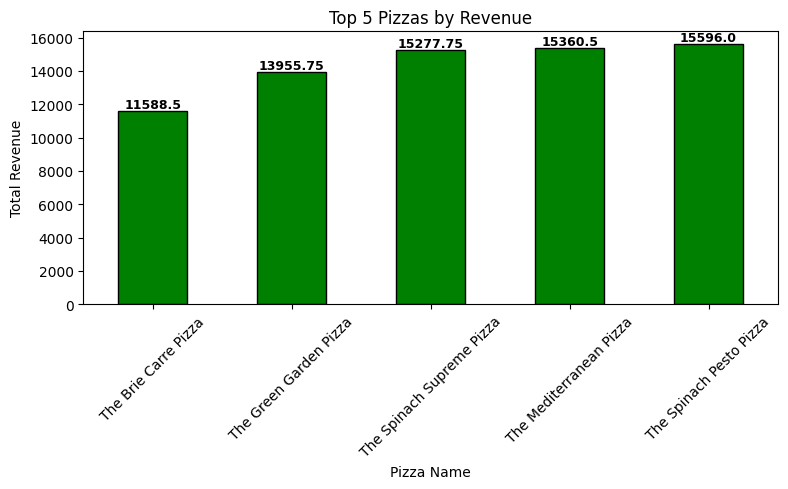

In [37]:
# buttom 5 Best-Selling Pizzas - Total Sales
pizzas_by_name = df.groupby('pizza_name')['total_price'].sum()

buttom5 = pizzas_by_name.sort_values(ascending=True).head(5)

ax = buttom5.plot(kind='bar', figsize=(8,5), color='green', edgecolor='black')
plt.title("Top 5 Pizzas by Revenue")
plt.xlabel("Pizza Name")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

for i, val in enumerate(buttom5):
    plt.text(i, val + 2, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

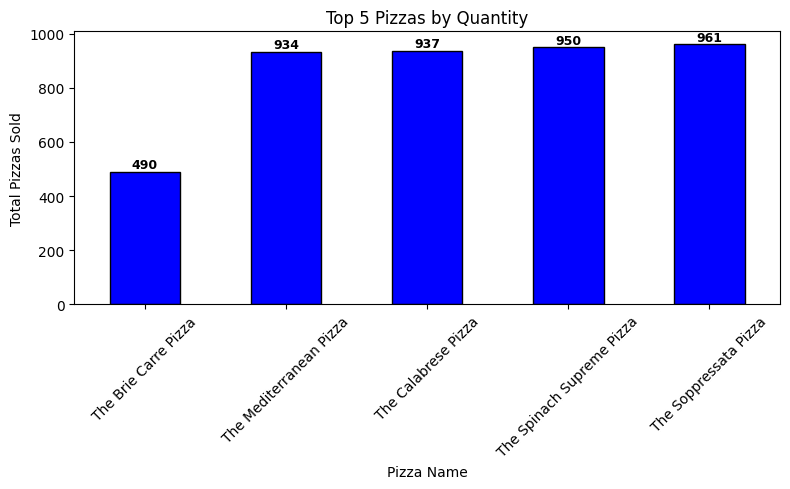

In [40]:
# Buttom 5 Best-Selling Pizzas - Total Quantity
pizzas_by_name = df.groupby('pizza_name')['quantity'].sum()

buttom5 = pizzas_by_name.sort_values(ascending=True).head(5)

ax = buttom5.plot(kind='bar', figsize=(8,5), color='blue', edgecolor='black')
plt.title("Top 5 Pizzas by Quantity")
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

for i, val in enumerate(buttom5):
    plt.text(i, val + 2, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Business Qustion Answered